## 7.6 게이트 순환 신경망(GRU)
GRU(Grated Recurrent Unit)는 게이트 메커니즘이 적용된 RNN 프레임워크의 한 종류이면서 LSTM보다 구조가 간단하다.

### 7.6.1 GRU 구조
GRU는 LSTM에서 사용하는 망각 게이트와 입력 게이트를 하나로 합친 것이며, 별도의 업데이트 게이트로 구성되어 있다. 하나의 게이트 컨트롤러가 망각 게이트와 입력 게이트를 모두 제어한다. 게이트 컨트롤러가 1을 출력하면 망각 게이트는 열리고 입력 게이트는 닫히며, 반대로 0을 출력하면 망각 게이트는 닫히고 입력 게이트는 열린다. 즉, 이전 기억이 저장될 때마다 단계별 입력은 삭제된다. GRU는 출력 게이트가 없어 전체 상태 벡터가 매 단계마다 출력되며, 이전 상태의 어느 부분이 출력될지 제어하는 새로운 게이트 컨트롤러가 별도로 존재한다.

#### 망각 게이트
망각 게이트는 과거 정보를 적당히 초기화시키려는 목적으로 시그모이드 함수를 출력으로 이용하여 (0,1) 값을 이전 은닉층에 곱한다. 이전 시점의 은닉층 값에 현시점의 정보에 대한 가중치를 곱한 것으로 수식은 다음과 같다.

image.png

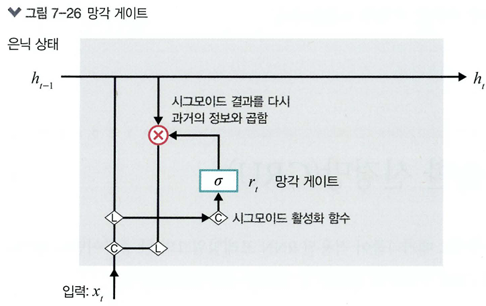

#### 업데이트 게이트
업데이트 게이트는 과거의 현재 정보의 최신화 비율을 결정하는 역할을 한다. 시그모이드로 출력된 결과(z_t)는 현시점의 정보량을 결정하고 1에서 뺀 값(1-z_t)을 직점 시점의 은닉층 정보와 곱한다. 이를 수식으로 나타내면 다음과 같다.

image.png

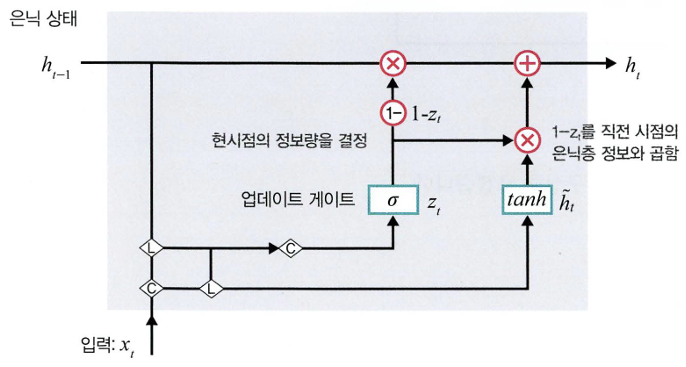

#### 후보군
후보군은 현시점 정보에 대한 후보군을 계산한다. 과거 은닉층의 정보를 그대로 이용하지 않고 망각 게이트의 결과를 이용하여 후보군을 계산한다.

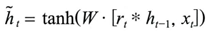

(*는 점 단위 연산이다. 예를 들어 벡터를 더할 때 각각의 차원에 맞게 곱하거나 더하는 것이 가능해진다.)


#### 은닉층 계산
마지막으로 업데이트 게이트 결과와 후보군 결과를 결합하여 현시점의 은닉층을 계산한다. 시그모이드 함수의 결과는 현시점에서 결과에 대한 정보량을 결정하고, 1-시그모이드 함수의 결과는 과거의 정보량을 결정한다. 이것을 수식으로 나타내면 다음과 같다.

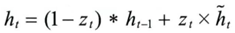

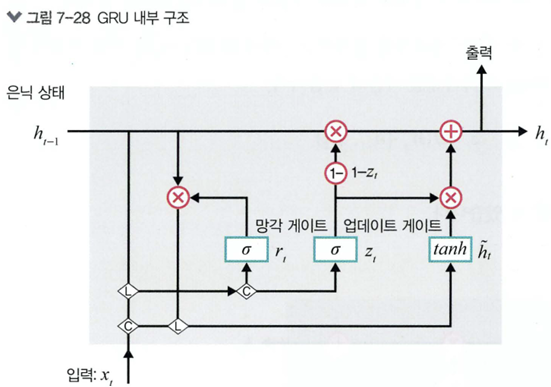

### 7.6.2 GRU 셀 구현
데이터셋 및 대부분의 코드는 LSTM 셀과 동일하다.먼저 필요한 라이브러리를 호출한다.

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn .functional as F
from torch.utils.data import DataLoader
import math
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
cuda = True if torch.cuda.is_available() else False

Tensor = torch.cuda.FloatTensor if cuda else torch .FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(125)

데이터셋을 평균과 표준편차를 기준으로 정규화하고 텐서로 변경하는 전처리를 진행한다.

In [2]:
mnist_transform = transforms .Compose([ transforms.ToTensor(), transforms.Normalize((0.5,), (1.0,)) ])

GRU 셋에서도 MNIST 데이터셋을 사용합니다. MNIST 데이터셋을 내려받은 후 전처리를 적용한다.

In [3]:
from torchvision.datasets import MNIST

from google.colab import drive
drive.mount('/content/drive')

download_root = '/content/drive/MyDrive/MNIST/MNIST_DATASET'

train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True) #1
valid_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


데이터로더를 이용하여 전처리된 데이터셋을 메모리로 불러온다. 단 메모리로 불러오는 시점은 train_loader, valid_loader, test_loader가 호출되는 시점이다.

In [4]:
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True) #일반적으로 검증과 테스트 용도의 데이터셋은 섞어서
test_loader = DataLoader(dataset=test_dataset,batch_size=batch_size, shuffle=True )

필요한 변수에 대한 값을 설정한다.

In [5]:
batch_size=100
n_iters=6000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs=int(num_epochs)

이제 집중해서 살펴보아야 할 GPU 셀에 대한 네트워크입니다. LSTM 셀과 크게 다르지 않지만 차이점 위주로 본다.

In [6]:
class GRUCell (nn .Module ):
  def __init__ (self, input_size, hidden_size, bias=True ):
    super(GRUCell , self). __init__ ()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias
    self.x2h = nn.Linear(input_size, 3 * hidden_size, bias=bias ) #1
    self.h2h = nn.Linear(hidden_size, 3 * hidden_size, bias=bias)
    self.reset_parameters ()

  def reset_parameters (self): # 파라미터를 초기화
    std = 1.0 / math.sqrt(self. hidden_size)
    for w in self.parameters():
      w.data.uniform_(-std, std)

  def forward (self, x, hidden ):
    x = x.view(-1 , x.size(1))
    gate_x = self.x2h (x) # LSTM 셀에서는 gates를 x2h+h2h로 정의했지만 GRU 셀에서는 개별적인 상태를 유지한다.
    gate_h = self.h2h (hidden)
    gate_x = gate_x.squeeze()
    gate_h=gate_h.squeeze()

    i_r, i_i, i_n = gate_x. chunk (3, 1) # 총 세 개의 게이트(망각，입력，새로운 게이트)를 위해 세 개로 쪼갠다.
    h_r , h_i , h_n = gate_h.chunk( 3, 1)

    resetgate = F.sigmoid( i_r + h_r )
    inputgate = F.sigmoid( i_i + h_i )
    newgate = F. tanh (i_n + (resetgate * h_n)) # '새로운 게이트'는 탄젠트 활성화 함수가 적용된 게이트

    hy = newgate + inputgate * (hidden - newgate)
    return hy

1. LSTM 셀에서는 4를 곱했지만 GRU 셀에서는 세 개의 게이트가 사용되므로 3을 곱한다. 엄밀히 게이트는 두 개(망각, 입력 게이트)이지만 탄젠트 활성화 함수가 적용되는 부분을 '새로운 게이트'로 정의하여 총 3을 곱한다.

개별적인 GRU 셀의 네트워크가 구성되었기 때문에 전반적인 네트워크에 대해 살펴본다.

In [7]:
class GRUModel(nn.Module):
  def __init__ (self, input_dim , hidden_dim , layer_dim , output_dim , bias=True ):
    super(GRUModel , self). __init__()
    self. hidden_dim = hidden_dim
    self.layer_dim = layer_dim

    self .gru_cell = GRUCell(input_dim, hidden_dim, layer_dim) #앞에서 정의한 GRUCell 함수를 불러옴
    self.fc = nn.Linear(hidden_dim, output_dim )

  def forward(self, x):
    if torch.cuda.is_available():
      h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
    else:
      h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim ))

    outs = []
    hn = h0 [0,:,:] # LSTM 셀에서는 셀 상태에 대해서도 정의했었지만 GRU 셀에서는 셀은 사용되지 않습니다.

    for seq in range (x.size(1)):
      hn = self.gru_cell(x[: ,seq,:], hn )
      outs.append (hn)
      out = outs [-1].squeeze()
      out = self.fc(out)
      return out

모델에 적용될 변수 값 및 옵티마이저와 손실 함수를 설정한다.

In [8]:
input_dim=28
hidden_dim=128
layer_dim=1
output_dim=10

model=GRUModel(input_dim, hidden_dim, layer_dim, output_dim)

if torch.cuda.is_available():
  model.cuda()

criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model .parameters() , lr=learning_rate)


훈련 데이터셋을 이용하여 모델을 학습시키고 검증 데이터셋을 이용하여 모델 성능을 측정한다.

In [9]:
seq_dim = 28
loss_list = []
iter = 0
for epoch in range (num_epochs):
  for i, (images , labels ) in enumerate (train_loader):
    if torch.cuda.is_available():
      images = Variable(images .view(-1 , seq_dim, input_dim).cuda())
      labels = Variable( labels .cuda())
    else :
      images = Variable(images .view(-1, seq_dim, input_dim))
      labels = Variable(labels)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)

    if torch.cuda .is_available():
      loss.cuda()

    loss.backward()
    optimizer.step()

    loss_list.append (loss.item())
    iter += 1

    if iter % 500 == 0:
      correct = 0
      total = 0
      for images, labels in valid_loader:
        if torch.cuda.is_available():
          images = Variable(images.view(-1 , seq_dim, input_dim).cuda())
        else:
          images = Variable(images .view(-1 , seq_dim, input_dim))

        outputs = model( images )
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)

        if torch.cuda.is_available():
          correct += (predicted.cpu() == labels.cpu()) .sum()
        else:
          correct += (predicted == labels).sum()

      accuracy = 100 * correct / total
      print( 'Iteration: {} . Loss : {} . Accuracy : {}' .format (iter, loss .item(), accuracy))

Iteration: 500 . Loss : 2.3020684719085693 . Accuracy : 10.319999694824219
Iteration: 1000 . Loss : 2.310199499130249 . Accuracy : 11.350000381469727
Iteration: 1500 . Loss : 2.306101083755493 . Accuracy : 11.350000381469727
Iteration: 2000 . Loss : 2.300555944442749 . Accuracy : 11.350000381469727
Iteration: 2500 . Loss : 2.2927582263946533 . Accuracy : 11.350000381469727
Iteration: 3000 . Loss : 2.309049606323242 . Accuracy : 11.350000381469727
Iteration: 3500 . Loss : 2.3057706356048584 . Accuracy : 11.350000381469727
Iteration: 4000 . Loss : 2.304710865020752 . Accuracy : 11.350000381469727
Iteration: 4500 . Loss : 2.3079323768615723 . Accuracy : 11.350000381469727
Iteration: 5000 . Loss : 2.2947354316711426 . Accuracy : 11.350000381469727
Iteration: 5500 . Loss : 2.2989981174468994 . Accuracy : 11.350000381469727
Iteration: 6000 . Loss : 2.3024723529815674 . Accuracy : 11.350000381469727
Iteration: 6500 . Loss : 2.3102259635925293 . Accuracy : 11.350000381469727
Iteration: 7000 . 

LSTM 셀을 실행했을 때의 정확도와 유사하다. 즉, LSTM 셀을 사용하든, GRU 셀을 사용하든 정확도가 비슷하게 나온다. 시계열 처리 관련한 모델(RNN, LSTM, GRU) 중 어떤 것이 더 좋다고 말할 수는 없다. 따라서 주어진 데이터셋을 다양한 모델에 적용하여 최적의 모델을 찾는 것이 중요하다. 테스트 데이터셋을 모델에 적용하여 예측에 대한 성능을 확인해본다.

In [10]:
def evaluate(model , val_iter):
  corrects, total, total_loss = 0, 0, 0
  model.eval()
  for images , labels in val_iter:
    if torch.cuda.is_available():
      images = Variable(images.view(-1, seq_dim, input_dim).cuda())
    else :
      images = Variable(images .view(-1, seq_dim, input_dim)).to(device)

    logit = model(images).to(device)
    loss = F.cross_entropy(logit, labels, reduction="sum")
    _, predicted = torch.max(logit.data, 1)
    total += labels.size(0)
    total_loss += loss.item()
    corrects += (predicted == labels).sum()

  avg_loss = total_loss / len(val_iter.dataset)
  avg_accuracy = corrects / total
  return avg_loss, avg_accuracy

모델의 예측력에 대한 성능 확인을 위해 테스트 데이터셋을 모델에 적용시킨다.

In [11]:
test_loss, test_acc = evaluate(model,test_loader)
print ("Test Loss: %5.2f : Test Accuracy: %5.2f" % (test_loss, test_acc))

Test Loss:  2.30 : Test Accuracy:  0.11


MINST 데이터셋에 대해서는 높은 성능을 보이지만 또 다른 데이터셋을 적용했을 때는 정확도가 낮게 나올 수 있다. 따라서 주어진 데이터셋에 대해 다양한 모델을 적용해보고 최적의 하이퍼파라미터를 찾는 것이 중요하다.

### 7.6.3 GRU 계층 구현
GRU 계층에 대해 파이토치를 이용한 예제를 살펴볼 예정이다. 이번 예제 또한 LSTM 계층에서 사용했던 데이터셋 및 코드와 유사하다. 따라서 모델의 네트워크 위주로 학습한다. 필요한 라이브러리를 호출한다.

In [12]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch .utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn .preprocessing import StandardScaler, MinMaxScaler
from sklearn .model_selection import train_test_split

device = torch.device( 'cuda:0' if torch.cuda.is_available() else 'cpu' )

스타벅스 주가 데이터셋을 불러와서 각 컬럼에 대한 데이터 형식을 살펴본다.

In [13]:
data = pd.read_csv('/content/drive/MyDrive/SBUX.csv')
print(data.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


'Date' 칼럼을 인덱스로 지정하고, 'Volume' 칼럼의 데이터 형식을 실수(float)로 변경한다. 참고로 대소문자를 구분하기 때문에 'Date'를 'date'로 사용하면 오류가 발생한다.

In [14]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index( 'Date', inplace=True )
data[ 'Volume' ] = data['Volume'].astype(float)

전체 칼럼 중 마지막 칼럼을 제외한 모든 데이터셋을 x(훈련 용도)로 지정하고 마지막 칼럼을 레이블(y)로 지정한다.

In [15]:
X = data.iloc[:, :-1]
y = data.iloc[: , 5:6]
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

앞에서 정의한 훈련과 레이블 데이터셋을 정규화하여 분포를 조정한다.

In [16]:
ms = MinMaxScaler()
ss = StandardScaler()

X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

X_train = X_ss [:200, : ]
X_test = X_ss [200: , :]

y_train = y_ms [:200, : ]
y_test = y_ms [200: , :]

print("Training Shape" , X_train .shape, y_train.shape)
print("Testing Shape" , X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


데이터셋을 LSTM 네트워크에 적용하기 위해 형태를 변겅한다.

In [17]:
X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors . shape[0], 1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors .shape[0], 1, X_test_tensors.shape[1]))

print ("Training Shape" , X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape" , X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


이제 GRU 모델의 네트워크를 살펴볼 텐데, 역시 LSTM 계층과의 차이점을 위주로 학습하는 것이 중요하다.

In [18]:
class GRU(nn.Module):
  def __init__ (self, num_classes, input_size, hidden_size, num_layers , seq_length):
    super(GRU, self).__init__()
    self.num_classes = num_classes
    self.num_layers = num_layers
    self.hidden_size = hidden_size
    self.seq_length = seq_length

    self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
    self.fc_1 = nn.Linear(hidden_size, 128)
    self.fc = nn.Linear(128, num_classes)
    self.relu = nn.ReLU()

  def forward(self, x):
    h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 은닉 상태에 대해 0으로 초기화하는 부분으로, LSTM 계층은 셀 상태가 있었지만 GRU는 셀 상태를 정의하지 않음
    output, (hn) = self.gru(x, (h_0))
    hn = hn .view(-1 , self.hidden_size)
    out = self.relu(hn)
    out = self.fc_1(out)
    out = self.relu(out)
    out = self.fc(out)
    return out

모델을 훈련시키기 위해 변수 값 및 옵티마이저, 손실 함수도 지정한다.

In [19]:
num_epochs=1000
learning_rate=0.0001

input_size=5
hidden_size=2
num_layers=1 #GRU 계층의 개수

num_classes = 1
model = GRU( num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model. parameters(), lr=learning_rate)

준비된 데이터셋과 모델의 네트워크를 이용하여 모델을 학습시킨다.

In [20]:
for epoch in range(num_epochs):
  outputs = model.forward(X_train_tensors_f)
  optimizer.zero_grad()
  loss = criterion(outputs, y_train_tensors)
  loss.backward ()

  optimizer.step()
  if epoch % 100 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.11692
Epoch: 100, loss: 0.04124
Epoch: 200, loss: 0.03291
Epoch: 300, loss: 0.03008
Epoch: 400, loss: 0.02830
Epoch: 500, loss: 0.02701
Epoch: 600, loss: 0.02590
Epoch: 700, loss: 0.02486
Epoch: 800, loss: 0.02385
Epoch: 900, loss: 0.02284


데이터를 그래프로 출력하기 위한 준비를 한다.

In [21]:
df_x_ss = ss.transform(data.iloc[: , :-1])
df_y_ms = ms.transform(data.iloc[: , -1:])
df_x_ss = Variable(torch.Tensor(df_x_ss ))
df_y_ms = Variable(torch.Tensor( df_y_ms ))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss .shape[0] , 1, df_x_ss .shape[ 1]))

모델의 예측 결과와 레이블을 그래프로 출력한다.

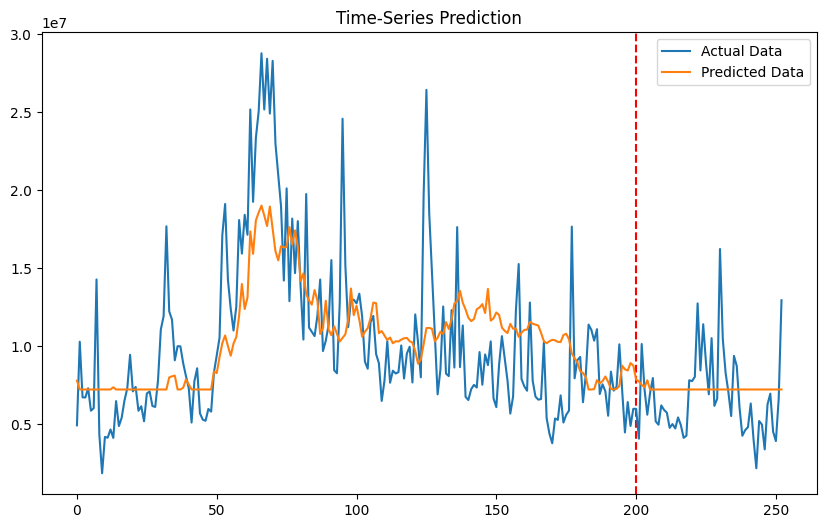

In [22]:
train_predict = model(df_x_ss)
predicted = train_predict.data.numpy()
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform(predicted)
label_y = ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200, c= 'r', linestyle='--')

plt.plot(label_y, label= 'Actual Data' )
plt.plot(predicted, label= 'Predicted Data')
plt.title( 'Time-Series Prediction' )
plt.legend()
plt. show()

그래프상으로는 GRU 계층을 사용했을 때가 LSTM 계층을 사용했을 때보다 예측력이 더 좋아 보인다. 하지만 수치상으로 모델의 예측 정확도는 유사했다.

## 7.7 양방향 RNN
RNN은 이전 시점의 데이터들을 참고해서 정답을 예측하지만 실제 문제에서는 과거 시점이 아닌 미래 시점의 데이터에 힌트가 있는 경우도 많다. 따라서 이전 시점의 데이터 뿐만 아니라, 이후 시점의 데이터도 함꼐 활용하여 출력 값을 예측하고자 하는 것이 양방향 RNN이다.

### 7.7.1 양방향 RNN 구조
양방향 RNN은 하나의 출력 값을 예측하는 데 메모리 셀 두 개를 사용한다. 첫 번째 메모리 셀은 이전 시점의 은닉 상태를 전달받아 현재의 은닉 상태를 계산한다. 다음 그림에서는 초록색 메모리 셀에 해당된다. 두 번째 메모리 셀은 다음 시점의 은닉 상태를 전달받아 현재의 은닉 상태를 계산한다. 다음 그림의 노란색 메모리 셀에 해당된다. 그리고 이 값 두 개를 모두 출력층에서 출력값을 예측하는 데 사용한다.

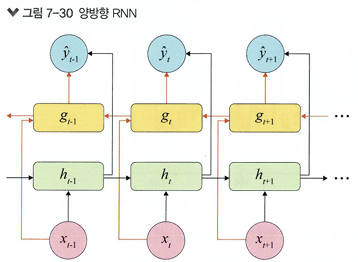

양방향 RNN에 대한 개념은 RNN뿐만 아니라 LSTM이나 GRU에도 적용된다. 예제는 양방향 LSTM으로 구현해본다.

### 7.7.2 양방향 LSTM 구현
계속 스타벅스 주가 예측 데이터셋을 사용한 예제를 살펴본다. 예제 코드 역시 LSTM 계층에서 사용했던 코드와 동일하다. LSTM 계층과 양방향 LSTM이 어떻게 다른지 네트워크 위주로 살펴본다. 다음은 모델의 네트워크 이전까지의 모든 코드이다.

In [23]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch .utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn .preprocessing import StandardScaler, MinMaxScaler
from sklearn .model_selection import train_test_split

device = torch.device( 'cuda:0' if torch.cuda.is_available() else 'cpu' )

data = pd.read_csv('/content/drive/MyDrive/SBUX.csv')
print(data.dtypes)

data['Date'] = pd.to_datetime(data['Date'])
data.set_index( 'Date', inplace=True )
data[ 'Volume' ] = data['Volume'].astype(float)

X = data.iloc[:, :-1]
y = data.iloc[: , 5:6]

ms = MinMaxScaler()
ss = StandardScaler()

X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

X_train = X_ss [:200, : ]
X_test = X_ss [200: , :]

y_train = y_ms [:200, : ]
y_test = y_ms [200: , :]

X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors . shape[0], 1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors .shape[0], 1, X_test_tensors.shape[1]))

print ("Training Shape" , X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape" , X_test_tensors_f.shape, y_test_tensors.shape)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


이제 집중해서 살펴보아야 할 양방향 LSTM에 대한 네트워크 부분이다.

In [24]:
class biLSTM(nn.Module):
  def __init__ (self, num_classes, input_size, hidden_size, num_layers, seq_length ):
    super(biLSTM, self). __init__()
    self.num_classes = num_classes
    self.num_layers = num_layers
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.seq_length = seq_length

    self.lstm = nn.LSTM( input_size=input_size, hidden_size=hidden_size,
                        num_layers=num_layers, bidirectional=True, batch_first=True ) #1
    self.fc = nn. Linear(hidden_size*2, num_classes) #2
    self.relu = nn.ReLU()

  def forward (self,x):
    h_0 = Variable( torch. zeros (self.num_layers*2 , x. size( 0), self. hidden_size)) #2'
    c_0 = Variable( torch. zeros (self.num_layers*2, x. size( 0), self . hidden_size)) #2''
    out, _ = self.lstm(x, (h_0, c_0))
    out = self.fc(out[: , - 1, :]) #마지막 시간(time step상 마지막단계)의 은닉상태
    out = self.relu(out)
    return out

- 1 LSTM 계층을 정의하는 부분(nn.LSTM)에 bidirectional=True 옵션을 사용하면 양방향 LSTM을 사용하겠다는 의미이다. 이와 같이 양방향 LSTM은 옵션 변경만으로 손쉽게 구현할 수 있다. bidirectional=True 옵션은 양방향 RNN, 양방향 GRU 모두에 해당된다.
- 2, 2', 2'' LSTM과 양방향 LSTM의 차이는 다음 그림과 같다. 입력 데이터가 전방향과 역방향 학습에 모두 전달되며 그 결과들도 모두 출력에 반영된다. 즉, 한 번 학습하는 데 두 개의 계층이 필요하기 때문에 LSTM과는 다르게 은닉 상태, 셀 상태에 2를 곱하고 마지막 출력층에도 2를 곱해야 한다(num_layers=1로 정의했지만 다음 그름과 같이 마치 두 개의 계층을 사용하는 것과 같기 때문에 2를 곱한다).

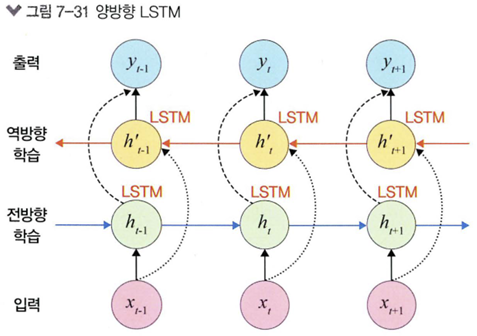

이제 양방향 LSTM 모델을 학습시킨다.

In [25]:
num_epochs=1000
learning_rate=0.0001

input_size = 5
hidden_size = 2
num_layers = 1

num_classes = 1
model = biLSTM( num_classes , input_size, hidden_size, num_layers , X_train_tensors_f.shape[1])

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters() , lr=learning_rate)

for epoch in range (num_epochs):
  outputs = model.forward(X_train_tensors_f)
  optimizer.zero_grad()

  loss = criterion(outputs, y_train_tensors)
  loss.backward()
  optimizer.step()
  if epoch % 100 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.04069
Epoch: 100, loss: 0.03687
Epoch: 200, loss: 0.03386
Epoch: 300, loss: 0.03143
Epoch: 400, loss: 0.02948
Epoch: 500, loss: 0.02797
Epoch: 600, loss: 0.02681
Epoch: 700, loss: 0.02592
Epoch: 800, loss: 0.02522
Epoch: 900, loss: 0.02466


학습이 진행될수록 오차가 줄어들고 있어 훈련이 잘된 것 같지만 어느 정도 잘된 것인지 알기 어렵다. 그래프를 통해서 모델의 예측력을 알아본다.

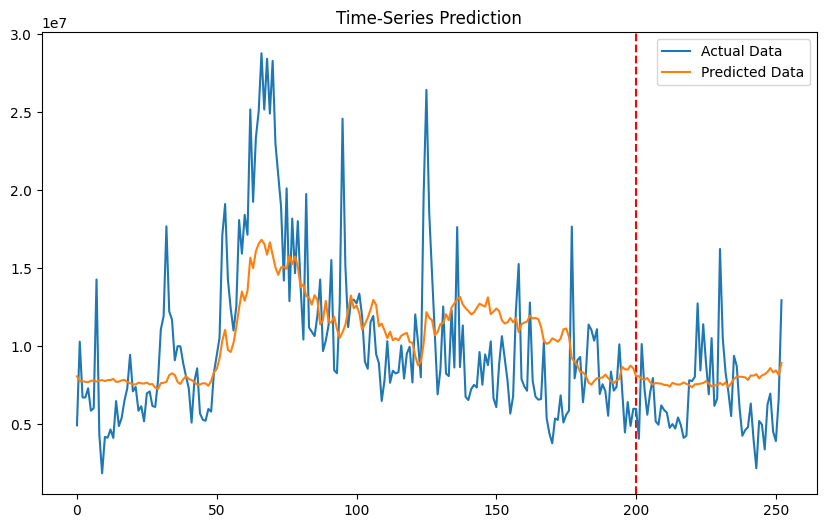

In [26]:
df_x_ss = ss.transform(data.iloc[: , :-1])
df_y_ms = ms.transform(data.iloc[: , -1:])

df_x_ss = Variable(torch.Tensor(df_x_ss ))
df_y_ms = Variable(torch.Tensor( df_y_ms ))

df_x_ss = torch.reshape(df_x_ss, (df_x_ss .shape[0] , 1, df_x_ss .shape[ 1]))

train_predict = model(df_x_ss)
predicted = train_predict.data.numpy()
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform(predicted)
label_y = ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200, c= 'r', linestyle='--')

plt.plot(label_y, label= 'Actual Data' )
plt.plot(predicted, label= 'Predicted Data')
plt.title( 'Time-Series Prediction' )
plt.legend()
plt. show()


파란색은 실제 레이블에 대한 결과이고 주황색은 모델이 예측한 결과로 이 두개가 유사해서 예측력이 좋다고 할 수 있다. 따라서 LSTM과 비교했을 때 예측 결과는 좋다고 예측해볼 수 있다. 하지만 역시 다른 유형의 데이터를 사용한다면 결과는 다를 수 있다.

지금까지 시계열 분석과 관련한 다양한 모델의 구현 방법을 알아보았다. 살펴본 것처럼 구현하는 것은 어렵지 않으나 문제는 데이터에 대한 처리이다. 대체로 시계열 데이터들은 일반적인 숫자의 나열보다는 한글 및 영문으로 사람의 언어(자연어)로 구현된 데이터가 대부분이기 때문이다. 따라서 시계열 구현에서 가장 중요한 것은 데이터에 대한 전처리이다.